In [99]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
from torchinfo import summary

import numpy as np
import matplotlib.pyplot as plt

import time
import random


In [70]:
## Set seed

def set_seed():

    SEED_VALUE = 123

    random.seed(SEED_VALUE) # python's built in random module
    np.random.seed(SEED_VALUE) # numpy's random module
    torch.manual_seed(SEED_VALUE) # pytorch' seed fix
     
    ## FOR GPU CUDA seed fixing

    if torch.cuda.is_available():
        torch.cuda.manual_seed(SEED_VALUE) # set seed for single GPU
        torch.cuda.manual_seed_all(SEED_VALUE) # set seed formulti-GPU

        torch.backends.cudnn.deterministic=True
        # torch.backends.cudnn.benchmark=True

set_seed()


In [71]:

set_seed()

floats = np.random.rand(5)    

print(floats)

[0.69646919 0.28613933 0.22685145 0.55131477 0.71946897]


In [72]:
transform = transforms.Compose([transforms.ToTensor()])

# Setup training data
train_dataset = datasets.CIFAR10(root='./data', # location to download data to
                               train=True,    # get training data
                               download=True, # download data if it doesn't exist on disk
                               transform=transform, # transformations on data
                            #    target_transform=None # you can transform labels as well
                            ) 
# Setup testing data
test_dataset  = datasets.CIFAR10(root='./data', 
                               train=False,   # get test data
                               download=True, 
                               transform=transform
                            )


Files already downloaded and verified
Files already downloaded and verified


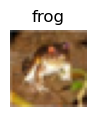

In [73]:
import matplotlib.pyplot as plt

image, label = train_dataset[0]

plt.figure(figsize=(2,1))
plt.imshow(image.permute(1,2,0))
# plt.title(f"Label: {label}")
plt.title(train_dataset.classes[label])
plt.axis("off")
plt.show()

In [74]:
all_pixels = []

for img, _ in train_dataset:
    pixels = img.view(-1)   # flatten image
    all_pixels.append(pixels)

all_pixels = torch.cat(all_pixels)

mean = all_pixels.mean().item()
std = all_pixels.std().item()

In [75]:
mean, std

(0.4733630120754242, 0.2515689432621002)

In [76]:
### transform the data >> zero mean , one std

In [77]:
# transform = transforms.Compose([
#     transforms.ToTensor(),
#     transforms.Normalize((mean,), (std,))
#     ])

# # Setup training data
# train_dataset = datasets.CIFAR10(root='./data', # location to download data to
#                                train=True,    # get training data
#                                download=True, # download data if it doesn't exist on disk
#                                transform=transform, # transformations on data
#                             #    target_transform=None # you can transform labels as well
#                             ) 
# # Setup testing data
# test_dataset  = datasets.CIFAR10(root='./data', 
#                                train=False,   # get test data
#                                download=True, 
#                                transform=transform
#                             )


In [78]:
all_pixels = []

for img, _ in train_dataset:
    pixels = img.view(-1)   # flatten image
    all_pixels.append(pixels)

all_pixels = torch.cat(all_pixels)

mean = all_pixels.mean().item()
std = all_pixels.std().item()

print(mean, std)

0.4733630120754242 0.2515689432621002


In [79]:
# How many samples are there? 
print("Train set:",len(train_dataset.data), len(train_dataset.targets))
print("Test Set:",len(test_dataset.data), len(test_dataset.targets))

Train set: 50000 50000
Test Set: 10000 10000


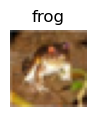

In [80]:
import matplotlib.pyplot as plt

image, label = train_dataset[0]

plt.figure(figsize=(2,1))
plt.imshow(image.permute(1,2,0))
# plt.title(f"Label: {label}")
plt.title(train_dataset.classes[label])
plt.axis("off")
plt.show()

In [81]:
from torch.utils.data import DataLoader

# Setup the batch size hyperparameter
BATCH_SIZE = 64


train_loader = DataLoader(train_dataset,         # dataset to turn into iterable
                          batch_size=BATCH_SIZE, # number of datapoints or samples per batch 
                          shuffle=True           # shuffle data every epoch
                        )

test_loader  = DataLoader(test_dataset, 
                          batch_size=BATCH_SIZE, 
                          shuffle=False          # don't necessarily have to shuffle the testing data
                        )

print(f"Dataloaders: {train_loader, test_loader}") 
print(f"Length of train dataloader: {len(train_loader)} batches of {BATCH_SIZE}")
print(f"Length of test dataloader: {len(test_loader)} batches of {BATCH_SIZE}")

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x158a84940>, <torch.utils.data.dataloader.DataLoader object at 0x158a84070>)
Length of train dataloader: 782 batches of 64
Length of test dataloader: 157 batches of 64


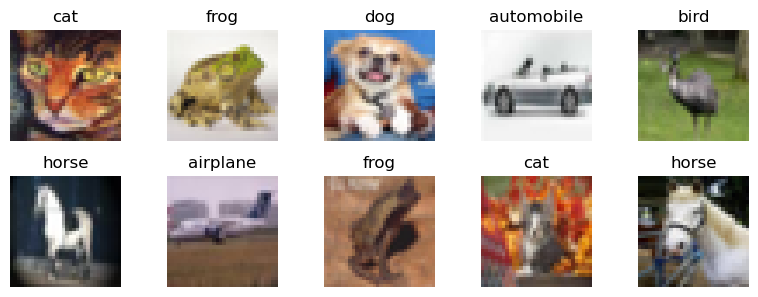

In [95]:
def visualize(loader, num_images=10):

    plt.figure(figsize=(8,6))

    images, labels = next(iter(loader))

    for i in range(num_images):
        img = images[i]

        # Handle grayscale vs RGB
        if img.shape[0] == 1:  # eg: MNIST
            img = img.squeeze(0)
            cmap = 'gray'
        else:  # eg: CIFAR
            img = img.permute(1, 2, 0)
            cmap = None

        plt.subplot(4, 5, i + 1)
        plt.imshow(img, cmap=cmap)
        plt.title(loader.dataset.classes[labels[i].item()])
        plt.axis('off')

    plt.tight_layout()
    plt.show()

visualize(train_loader)

In [96]:
image, label = train_dataset[0]

print(type(image)) # Image → Tensor
print(image.shape) # Shape → [1, 32, 32]
print(label)       # Label → integer (0–9)
print(train_dataset.classes[label])     

<class 'torch.Tensor'>
torch.Size([3, 32, 32])
6
frog


In [97]:

## MLP without sequential module

class MLP_old(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        # Layers
        self.fc0 = nn.Linear(3*32*32, 512)  # cifar 3,32,32 = rgb, 32,32 
        self.bn0 = nn.BatchNorm1d(512)

        self.fc1 = nn.Linear(512, 256)
        self.bn1 = nn.BatchNorm1d(256)

        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)

        self.fc3 = nn.Linear(128, 64)
        self.bn3 = nn.BatchNorm1d(64)

        self.fc4 = nn.Linear(64, num_classes)

        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        # Flatten. view() >> reshape tensor (32,-1) >> -1 automatically figure out the rest
        # Each image is flattened into a vector
        x = x.view(x.size(0), -1)

        # Layer 1
        x = self.fc0(x)
        x = self.bn0(x)
        x = F.relu(x)
        x = self.dropout(x)

        # Layer 2
        x = self.fc1(x)
        x = self.bn1(x)
        x = F.relu(x)

        # Layer 3
        x = self.fc2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout(x)

        # Layer 4
        x = self.fc3(x)
        x = self.bn3(x)
        x = F.relu(x)

        # Output
        x = self.fc4(x)

        return x

In [ ]:
class MLP(nn.Module):
    
    def __init__(self, num_classes=10):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(3*32*32, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)  # flatten
        return self.model(x)

In [100]:
mlp_model = MLP(num_classes=10)

In [101]:
summary(mlp_model)

Layer (type:depth-idx)                   Param #
MLP                                      --
├─Sequential: 1-1                        --
│    └─Linear: 2-1                       1,573,376
│    └─BatchNorm1d: 2-2                  1,024
│    └─ReLU: 2-3                         --
│    └─Dropout: 2-4                      --
│    └─Linear: 2-5                       131,328
│    └─BatchNorm1d: 2-6                  512
│    └─ReLU: 2-7                         --
│    └─Linear: 2-8                       32,896
│    └─BatchNorm1d: 2-9                  256
│    └─ReLU: 2-10                        --
│    └─Dropout: 2-11                     --
│    └─Linear: 2-12                      8,256
│    └─ReLU: 2-13                        --
│    └─Linear: 2-14                      650
Total params: 1,748,298
Trainable params: 1,748,298
Non-trainable params: 0

In [104]:
## Traning 

In [108]:
def train(model, train_loader, optimizer, criterion, device, epochs=10):
    model.to(device)

    loss_history = []
    acc_history = []

    for epoch in range(epochs):
        model.train()

        total_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            # Forward
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Metrics
            total_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        avg_loss = total_loss / len(train_loader)
        accuracy = 100 * correct / total

        loss_history.append(avg_loss)
        acc_history.append(accuracy)

        print(f"Epoch [{epoch+1}/{epochs}] | Loss: {avg_loss:.4f} | Acc: {accuracy:.2f}%")

    return loss_history, acc_history

In [109]:
model = MLP(num_classes=10)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
loss_hist, acc_hist = train(model, train_loader, optimizer, criterion, device)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(loss_hist)
plt.title("Loss vs Epoch")

plt.subplot(1,2,2)
plt.plot(acc_hist)
plt.title("Accuracy vs Epoch")

plt.show()

In [105]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")


Test Accuracy: 51.64%
